# Project specifications

- Primary task: Regression
- Dataset: Customer Personality Analysis (Kaggle)
- Problem Statement: Predict a customer's total spending, and segment customers by purchase behavior so the prediction feeds directly into a marketing persona.
- Deliverables:
EDA + preprocessing (handle missing income values, encode categoricals, scale)
Regression models — Ridge/Lasso, Random Forest Regressor, XGBoost Regressor — tuned, tracked in MLflow, evaluated on MAE/RMSE/R²

Clustering on spend-per-category, campaign response, recency, income — K-Means + 2 others, compared on silhouette score, into named personas (e.g. "high-value loyalists," "at-risk low spenders")
FastAPI: POST /predict (predicted spend) and GET /segment (persona)
Docker + Streamlit: input a customer profile → predicted spend + persona + suggested campaign


- Customer Personality Analysis is a detailed analysis of a company’s ideal customers. It helps a business to better understand its customers and makes it easier for them to modify products according to the specific needs, behaviors and concerns of different types of customers.

- Customer personality analysis helps a business to modify its product based on its target customers from different types of customer segments. For example, instead of spending money to market a new product to every customer in the company’s database, a company can analyze which customer segment is most likely to buy the product and then market the product only on that particular segment.

# Loading libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import mlflow
import mlflow.sklearn

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, TargetEncoder, FunctionTransformer
from sklearn.base import clone
from category_encoders import CountEncoder
from sklearn.linear_model import Ridge, Lasso
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, root_mean_squared_error

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture



- Loading the Dataset and exploring it

loaded dataset (likely using pd.read_csv()), pandas looked for standard comma separators (,), but your file is actually separated by tabs or spaces.
Depending on how file is formatted, pass the sep or delimiter parameter when reading the file.
- tabs, use sep='\t'
- variable amounts of spaces between columns: sep=r'\s+'

In [3]:
df = pd.read_csv('marketing_campaign.csv', sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [7]:
df.shape

(2240, 29)

In [8]:
df.duplicated().sum()

np.int64(0)

- missing values in income feature
- no duplicates

C:\Users\pooja\AppData\Local\Temp\ipykernel_16888\648890000.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col_name, ax=axes[i], palette='Blues_r')
C:\Users\pooja\AppData\Local\Temp\ipykernel_16888\648890000.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col_name, ax=axes[i], palette='Blues_r')
C:\Users\pooja\AppData\Local\Temp\ipykernel_16888\648890000.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col_name, ax=axes[i], palette='Blues_r')
C:\Users\pooja\AppData\Local\Te

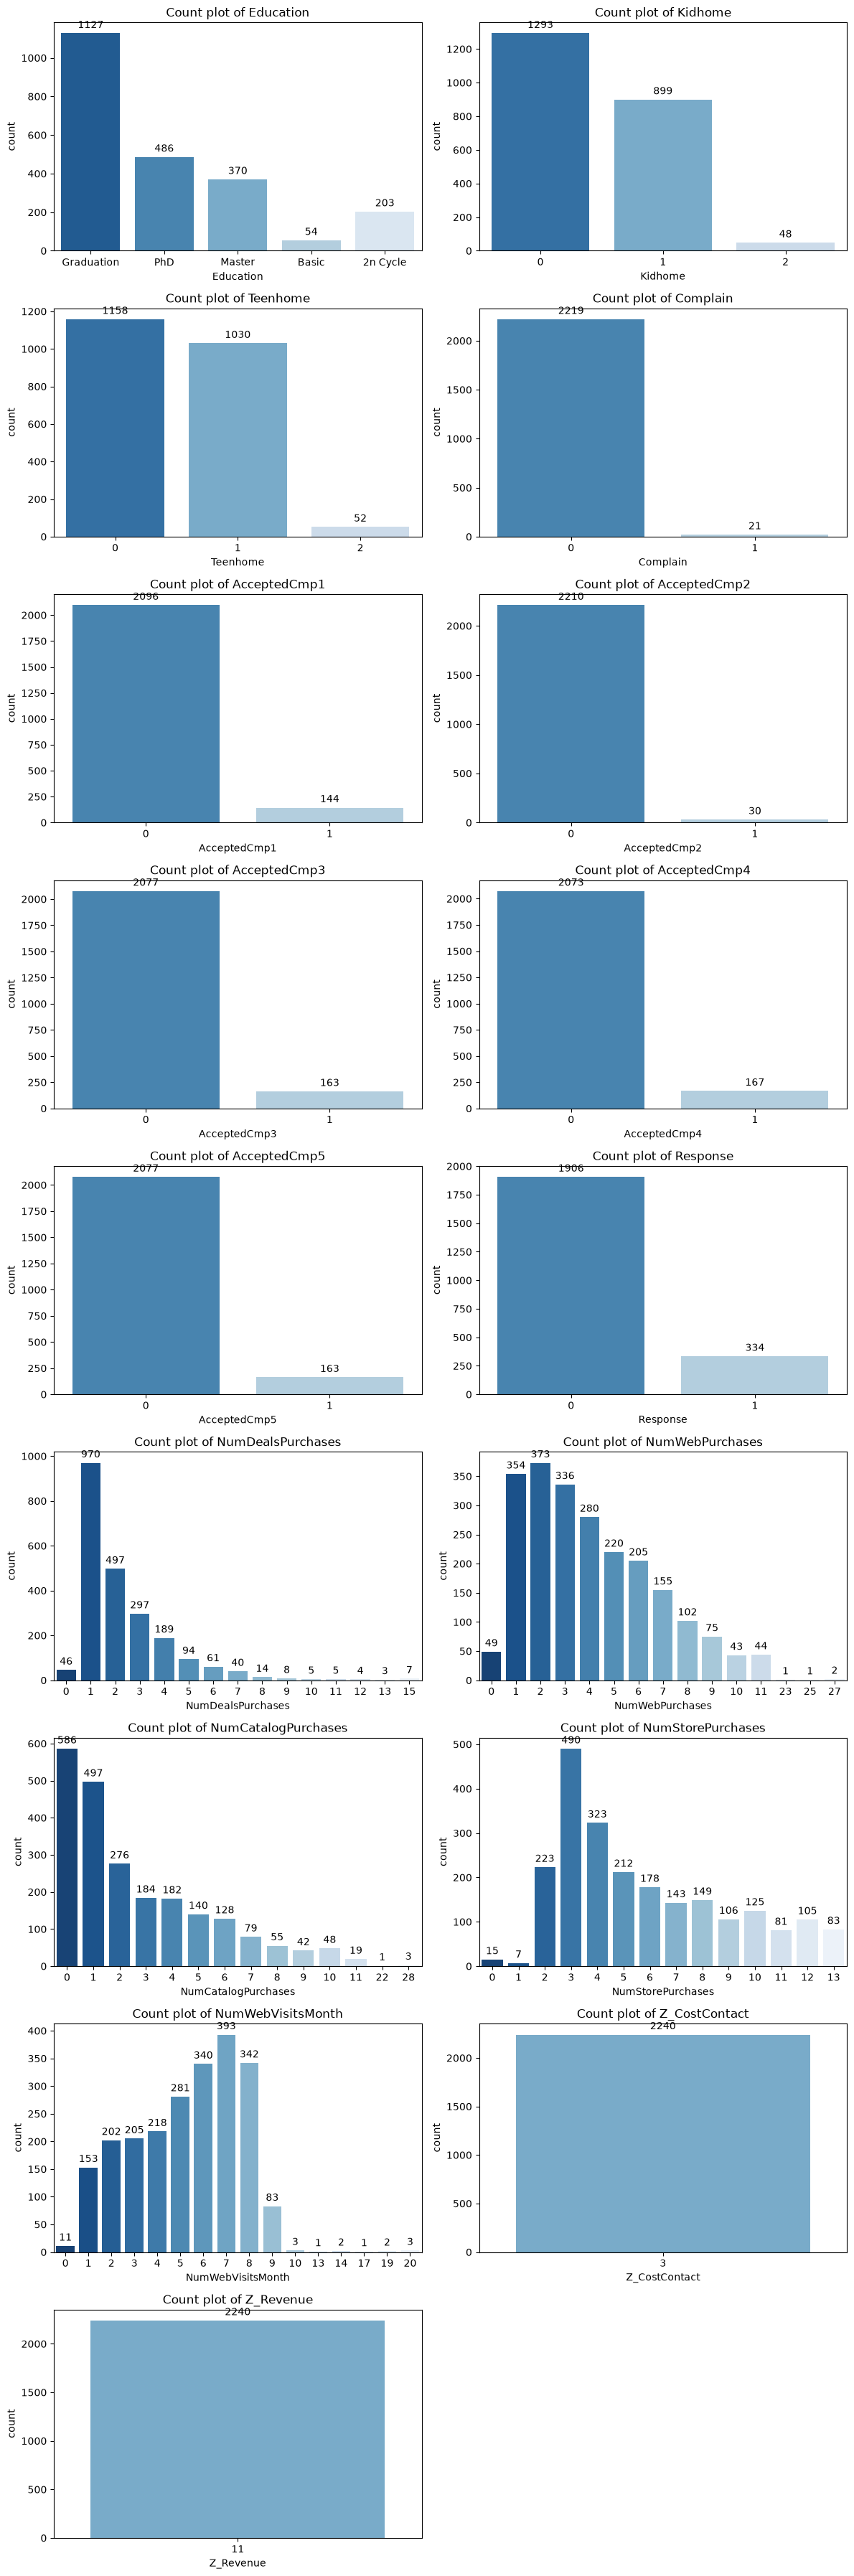

In [9]:
cat_cols = ['Education', 'Kidhome', 'Teenhome', 'Complain', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 
            'AcceptedCmp5', 'Response', 'NumDealsPurchases', 'NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
            'Z_CostContact', 'Z_Revenue']

col = 2
row = (len(cat_cols)+col -1)//col

fig, axes = plt.subplots(row, col, figsize=(12, 4*row))
axes = axes.flatten()

for i, col_name in enumerate(cat_cols):
    ax = sns.countplot(data=df, x=col_name, ax=axes[i], palette='Blues_r')
    axes[i].set_title(f'Count plot of {col_name}')
    for container in ax.containers:
        ax.bar_label(container, padding=3)

for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


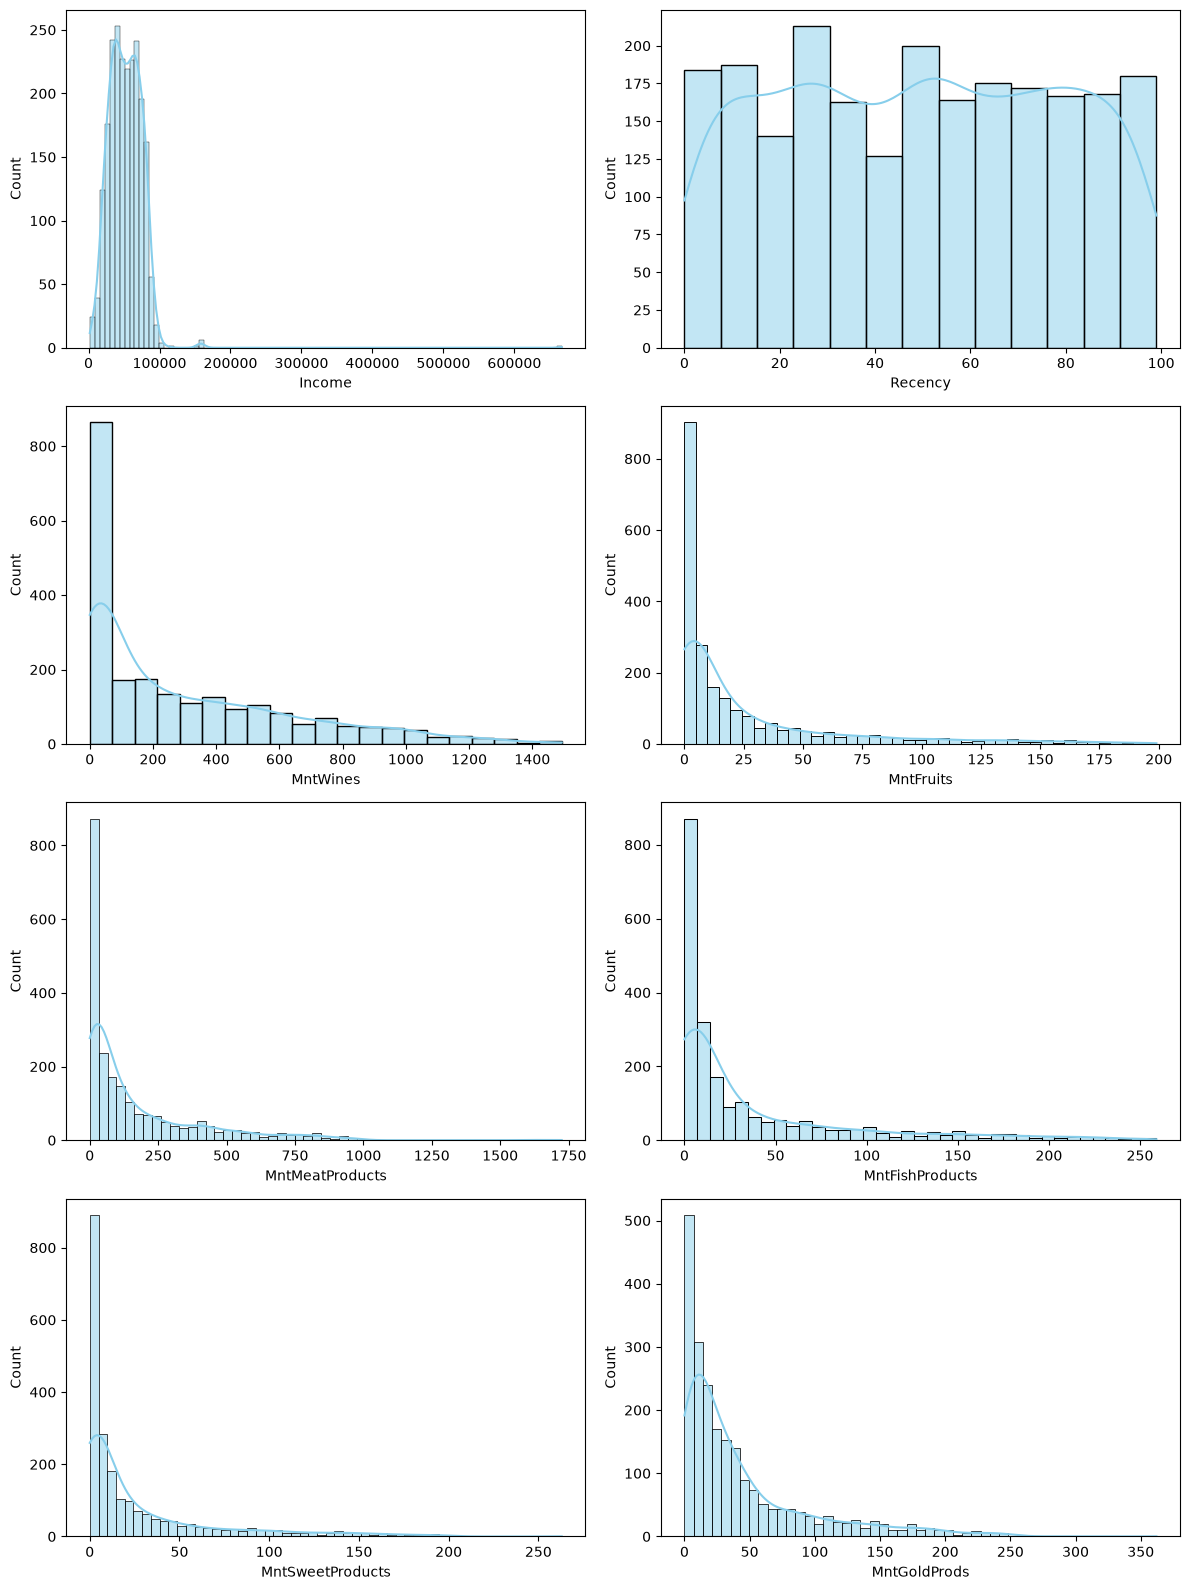

In [10]:
num_cols = ['Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

col = 2
row = (len(num_cols)+col -1)//col

fig1, axes1 = plt.subplots(row, col, figsize=(12, 4*row))
axes1 = axes1.flatten()

for i, col_name in enumerate(num_cols):
    sns.histplot(data=df, x=col_name, ax=axes1[i], kde=True, color='skyblue')
    axes[i].set_title(f'Distribution of {col_name}')

for j in range(len(num_cols), len(axes1)):
    fig1.delaxes(axes1[j])    
plt.tight_layout()
plt.show()

# Bivariate analysis

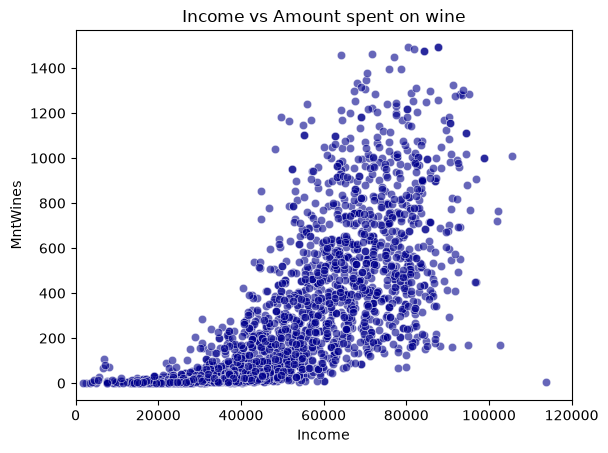

In [11]:
sns.scatterplot(data=df, x='Income', y='MntWines', alpha=0.6, color='darkblue')
plt.title('Income vs Amount spent on wine')
plt.xlim(0,120000)
plt.show()

C:\Users\pooja\AppData\Local\Temp\ipykernel_16888\2714362011.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Education', y='Income', palette='Set2')


Text(0.5, 1.0, 'Mean Income by Education')

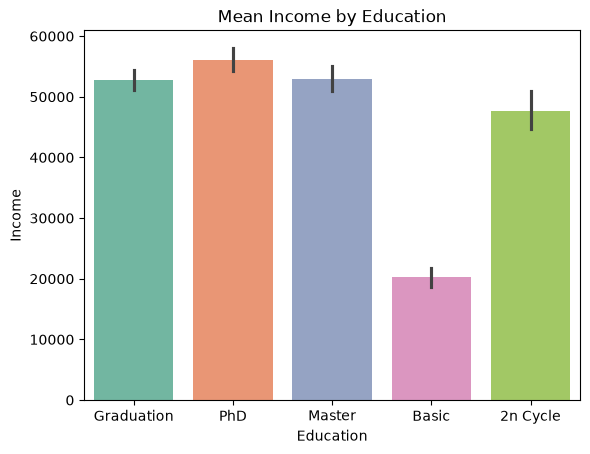

In [12]:
sns.barplot(data=df, x='Education', y='Income', palette='Set2')
plt.title('Mean Income by Education')

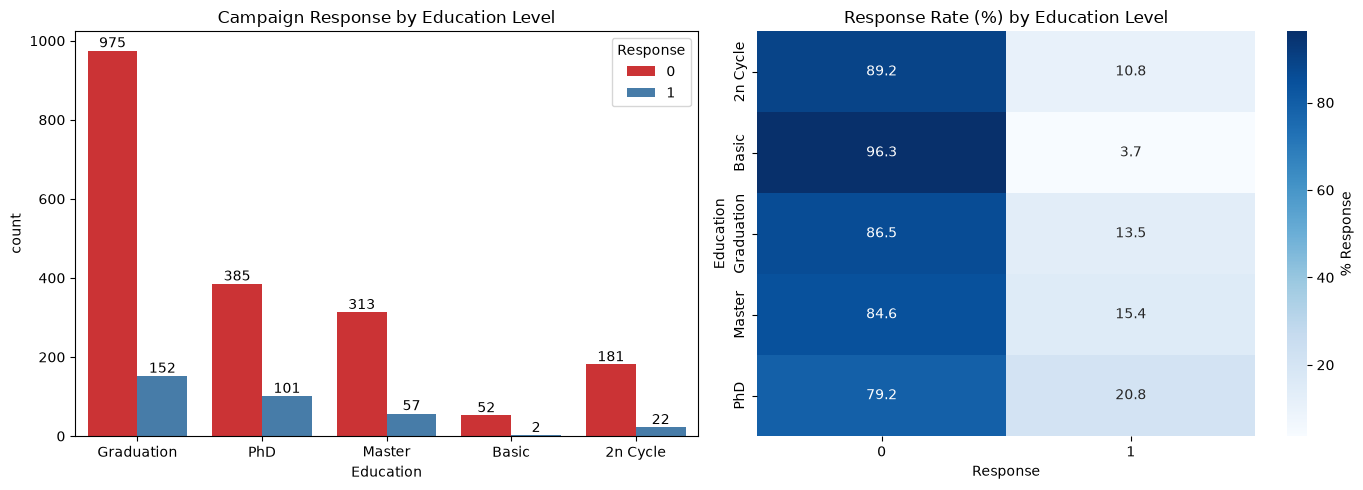

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Grouped Count Plot (Response rate by Education)
sns.countplot(data=df, x='Education', hue='Response', ax=axes[0], palette='Set1')
axes[0].set_title('Campaign Response by Education Level')

# Add numbers on top of bars
for container in axes[0].containers:
    axes[0].bar_label(container)

# 2. Heatmap of Cross-Tabulation (Proportions)
ct = pd.crosstab(df['Education'], df['Response'], normalize='index') * 100
sns.heatmap(ct, annot=True, fmt=".1f", cmap='Blues', ax=axes[1], cbar_kws={'label': '% Response'})
axes[1].set_title('Response Rate (%) by Education Level')

plt.tight_layout()
plt.show()

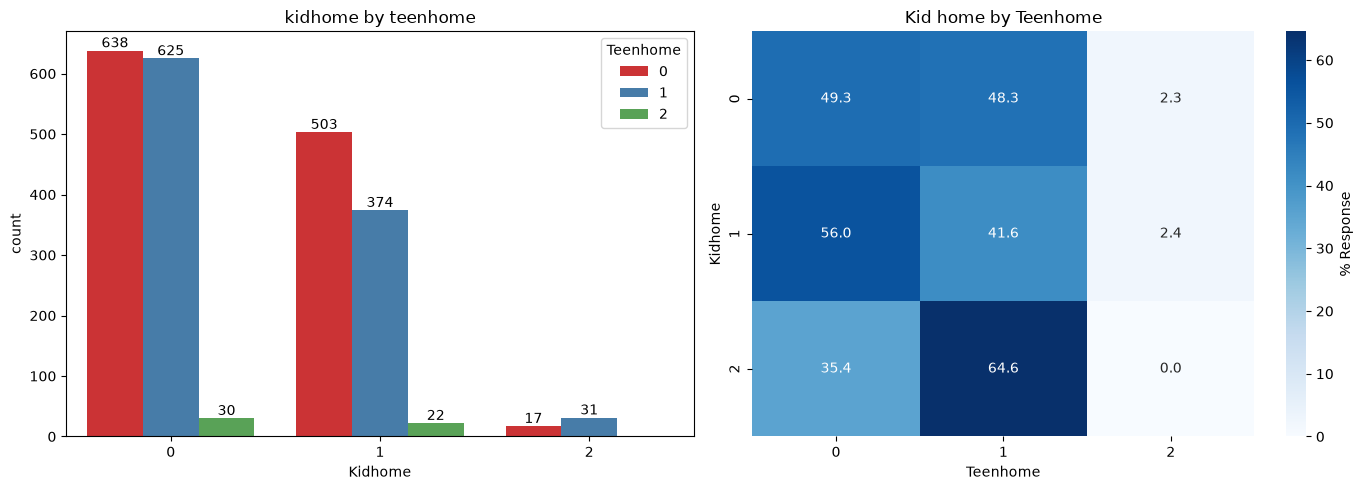

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Grouped Count Plot (Response rate by Education)
sns.countplot(data=df, x='Kidhome', hue='Teenhome', ax=axes[0], palette='Set1')
axes[0].set_title('kidhome by teenhome')

# Add numbers on top of bars
for container in axes[0].containers:
    axes[0].bar_label(container)

# 2. Heatmap of Cross-Tabulation (Proportions)
ct = pd.crosstab(df['Kidhome'], df['Teenhome'], normalize='index') * 100
sns.heatmap(ct, annot=True, fmt=".1f", cmap='Blues', ax=axes[1], cbar_kws={'label': '% Response'})
axes[1].set_title('Kid home by Teenhome')

plt.tight_layout()
plt.show()

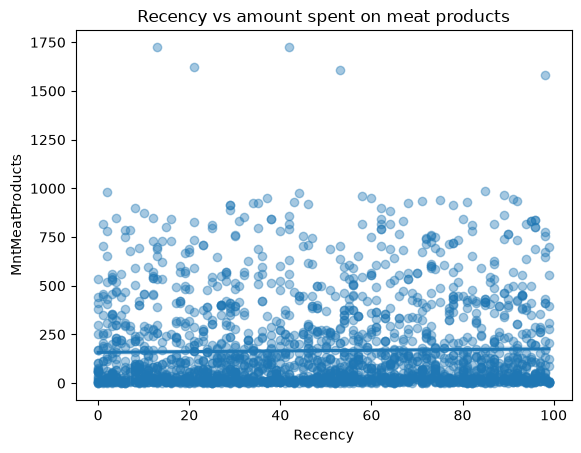

In [15]:
sns.regplot(data=df, x='Recency', y='MntMeatProducts', scatter_kws={'alpha':0.4})
plt.title('Recency vs amount spent on meat products')
plt.show()

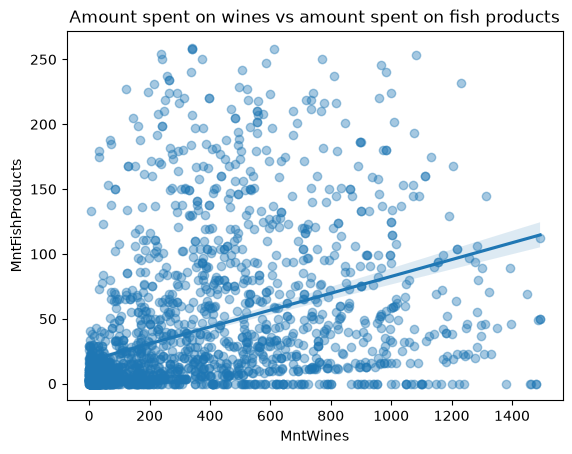

In [16]:
#['Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
sns.regplot(data=df, x='MntWines', y='MntFishProducts', scatter_kws={'alpha':0.4})
plt.title('Amount spent on wines vs amount spent on fish products')
plt.show()

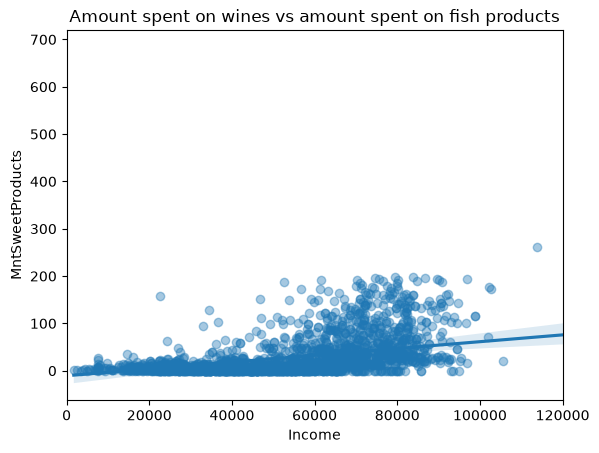

In [17]:
sns.regplot(data=df, x='Income', y='MntSweetProducts', scatter_kws={'alpha':0.4})
plt.title('Amount spent on wines vs amount spent on fish products')
plt.xlim(0,120000)
plt.show()

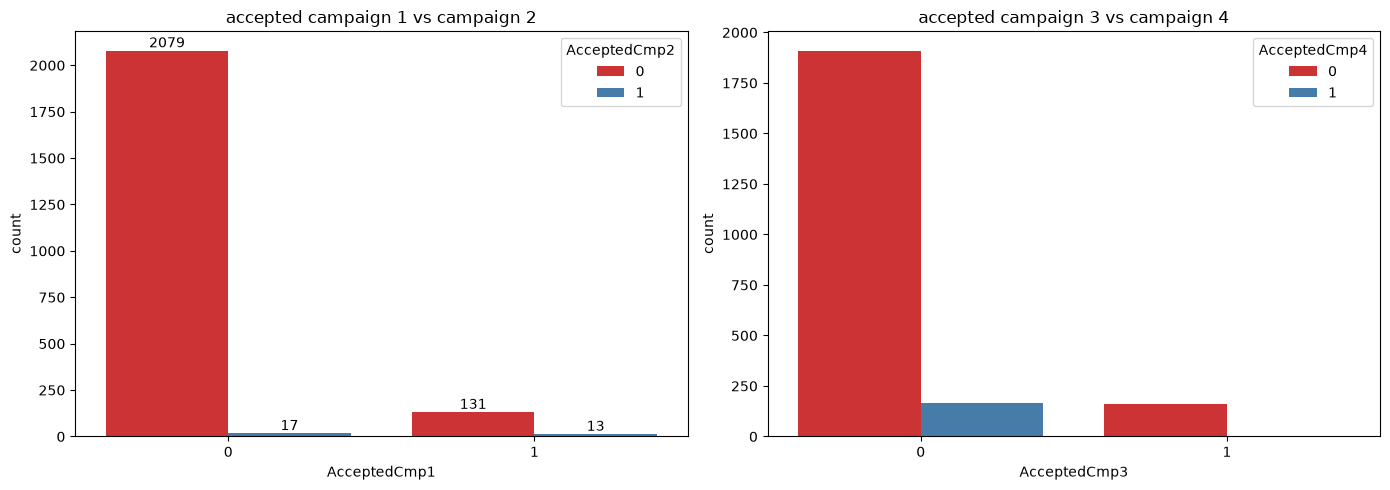

In [18]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Grouped Count Plot (Response rate by Education)
sns.countplot(data=df, x='AcceptedCmp1', hue='AcceptedCmp2', ax=axes[0], palette='Set1')
axes[0].set_title('accepted campaign 1 vs campaign 2')

# Add numbers on top of bars
for container in axes[0].containers:
    axes[0].bar_label(container)

sns.countplot(data=df, x='AcceptedCmp3', hue='AcceptedCmp4', ax=axes[1], palette='Set1')
axes[1].set_title('accepted campaign 3 vs campaign 4')

plt.tight_layout()
plt.show()

# Multivariate Analysis

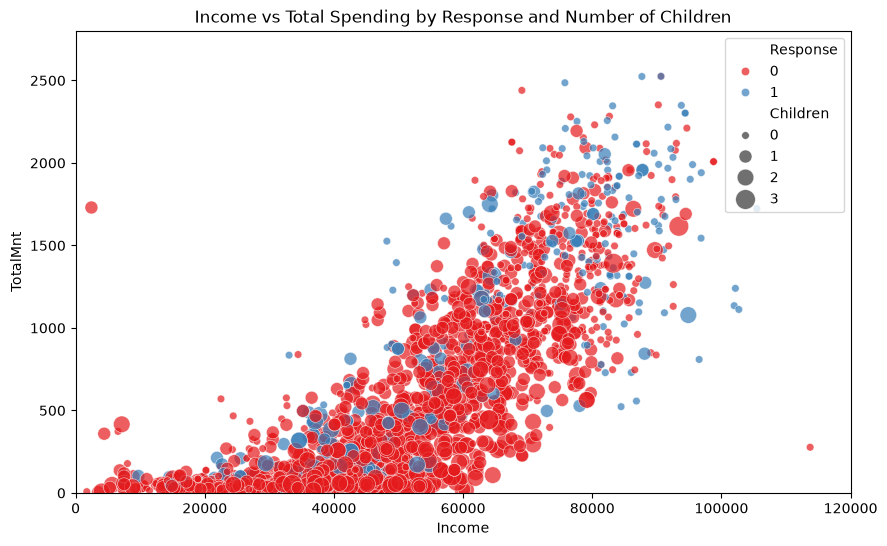

In [19]:
df_copy = df.copy()

# getting the toal expense amount
df_copy['TotalMnt'] = df[['MntWines', 'MntFruits', 'MntMeatProducts', 
                     'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)

#Number children
df_copy['Children'] = df['Kidhome'] + df['Teenhome']

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_copy, 
    x='Income', 
    y='TotalMnt', 
    hue='Response', 
    size='Children', 
    sizes=(30, 200),
    alpha=0.7, 
    palette='Set1'
)
plt.title('Income vs Total Spending by Response and Number of Children')
plt.xlim(0, 120000)
plt.ylim(0, 2800)
plt.show()

In [20]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [21]:
df_copy['Children'] = df_copy['Kidhome'] + df_copy['Teenhome']
df_copy = df_copy.drop(columns=['Kidhome', 'Teenhome'])

expense = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df_copy['Expense_amount'] = df_copy[expense].sum(axis=1)
df_copy = df_copy.drop(columns=expense)

df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Dt_Customer          2240 non-null   object 
 6   Recency              2240 non-null   int64  
 7   NumDealsPurchases    2240 non-null   int64  
 8   NumWebPurchases      2240 non-null   int64  
 9   NumCatalogPurchases  2240 non-null   int64  
 10  NumStorePurchases    2240 non-null   int64  
 11  NumWebVisitsMonth    2240 non-null   int64  
 12  AcceptedCmp3         2240 non-null   int64  
 13  AcceptedCmp4         2240 non-null   int64  
 14  AcceptedCmp5         2240 non-null   int64  
 15  AcceptedCmp1         2240 non-null   i

In [22]:
df_copy = df_copy.drop(columns=['Z_Revenue', 'Z_CostContact', 'TotalMnt'])
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Dt_Customer          2240 non-null   object 
 6   Recency              2240 non-null   int64  
 7   NumDealsPurchases    2240 non-null   int64  
 8   NumWebPurchases      2240 non-null   int64  
 9   NumCatalogPurchases  2240 non-null   int64  
 10  NumStorePurchases    2240 non-null   int64  
 11  NumWebVisitsMonth    2240 non-null   int64  
 12  AcceptedCmp3         2240 non-null   int64  
 13  AcceptedCmp4         2240 non-null   int64  
 14  AcceptedCmp5         2240 non-null   int64  
 15  AcceptedCmp1         2240 non-null   i

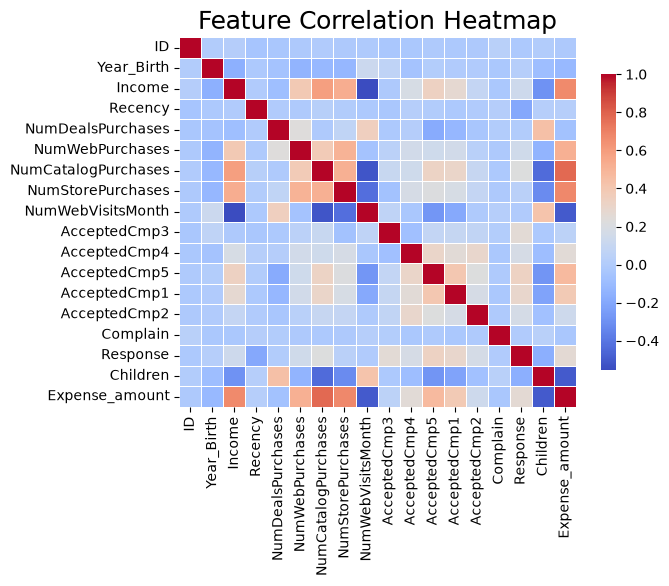

In [23]:

corr_matrix = df_copy.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=False, fmt=".2f", cmap='coolwarm', 
            linewidths=0.5, cbar_kws={"shrink": .8})

plt.title('Feature Correlation Heatmap', fontsize=18)
plt.show()

In [24]:
df_copy['Marital_Status'].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

# Dividing columns into categorical and numerical how to process it

C:\Users\pooja\AppData\Local\Temp\ipykernel_16888\3282070710.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_copy, x='Children', palette='Blues_r')


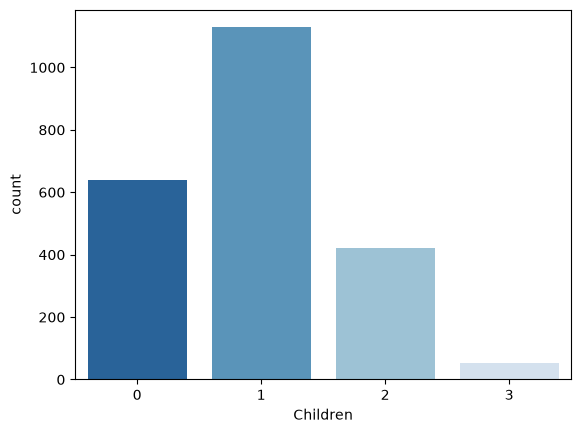

In [25]:
sns.countplot(data=df_copy, x='Children', palette='Blues_r')
plt.show()

In [26]:
enrollment_years = pd.to_datetime(df_copy['Dt_Customer'], format='%d-%m-%Y').dt.year.value_counts()
print("Customer Enrollment Breakdown by Year:\n", enrollment_years)

Customer Enrollment Breakdown by Year:
 Dt_Customer
2013    1189
2014     557
2012     494
Name: count, dtype: int64


# Pipeline processor
- Drop: ID
- Target: Expense_amount
- Numerical:
    - convert year birth to age then scale them
    - Scaling: NumDealsPurchases, NumWebPurchases,NumCatalogPurchases, NumStorePurchases, NumWebVisitsMonth, Income, Recency
- Categorical:
    - Binary: Response, Complain, AcceptedCmp1, AcceptedCmp2, AcceptedCmp3, AcceptedCmp4, AcceptedCmp5
    (keep as it is)
    - Ordinal: Education (Basic: 1, Bachelors: 2, 2ncycle, masters: 3, Phd: 4)
        - Marital_status: (Single: 0, Together: 1, Married: 1, Divorced: 0, Widow: 0, Alone: 0, Absurd: 0, YOLO: 0)
        - children (keep as it is)
        - convert Dt_Customer as (2012: 1, 2013: 2, 2014: 3)
- Missing values in income: Rightly skewed so impute it using median

In [27]:
df_copy['Age'] = 2014 - df_copy['Year_Birth']
df_copy = df_copy.drop(columns=['Year_Birth'])

# Train/test split

In [28]:
edu_map = {
            'Basic': 1,
            'Graduation': 2,
            '2n Cycle': 3,
            'Master': 3,
            'PhD': 4
        }

marital_map = {
            'Single': 0, 'Together': 1, 'Married': 1,
            'Divorced': 0, 'Widow': 0, 'Alone': 0,
            'Absurd': 0, 'YOLO': 0
        }

dt_years = pd.to_datetime(df_copy['Dt_Customer'], format='%d-%m-%Y', errors='coerce').dt.year
year_map = {2012: 1, 2013: 2, 2014: 3}

df_copy['Education'] = df_copy['Education'].map(edu_map)
df_copy['Marital_Status'] = df_copy['Marital_Status'].map(marital_map)
df_copy['Dt_Customer'] = dt_years.map(year_map)



In [29]:
df_copy.describe()

,ID,Education,Marital_Status,Income,Dt_Customer,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Children,Expense_amount,Age
count,2240.000000,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,2.665625,0.644643,52247.251354,2.028125,49.109375,2.325000,4.084821,2.662054,5.790179,...,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,0.149107,0.950446,605.798214,45.194196
std,3246.662198,0.839658,0.478728,25173.076661,0.684554,28.962453,1.932238,2.778714,2.923101,3.250958,...,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.356274,0.751803,602.249288,11.984069
min,0.000000,1.000000,0.000000,1730.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,18.000000
25%,2828.250000,2.000000,0.000000,35303.000000,2.000000,24.000000,1.000000,2.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,68.750000,37.000000
50%,5458.500000,2.000000,1.000000,51381.500000,2.000000,49.000000,2.000000,4.000000,2.000000,5.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,396.000000,44.000000
75%,8427.750000,3.000000,1.000000,68522.000000,2.000000,74.000000,3.000000,6.000000,4.000000,8.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1045.500000,55.000000
max,11191.000000,4.000000,1.000000,666666.000000,3.000000,99.000000,15.000000,27.000000,28.000000,13.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,2525.000000,121.000000


- age cannot be 121 

In [30]:
print(df_copy[df_copy['Age'] > 100])

        ID  Education  Marital_Status   Income  Dt_Customer  Recency  \
192   7829          3               0  36640.0            2       99   
239  11004          3               0  60182.0            3       23   
339   1150          4               1  83532.0            2       36   

     NumDealsPurchases  NumWebPurchases  NumCatalogPurchases  \
192                  1                2                    1   
239                  1                1                    0   
339                  1                4                    6   

     NumStorePurchases  ...  AcceptedCmp3  AcceptedCmp4  AcceptedCmp5  \
192                  2  ...             0             0             0   
239                  2  ...             0             0             0   
339                  4  ...             0             0             1   

     AcceptedCmp1  AcceptedCmp2  Complain  Response  Children  Expense_amount  \
192             0             0         1         0         1              65   

In [31]:
df_copy.loc[(df_copy['Age'] > 100), 'Age'] = np.nan

# Finding outliers

In [32]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

low, high = iqr_bounds(df_copy["Income"])
print(f"Income outlier bounds: {low:,.0f} to {high:,.0f}")
print("Income outliers:", ((df_copy["Income"] < low) | (df_copy["Income"] > high)).sum())

# Look at the flagged rows before deciding anything!
df_copy[(df_copy["Income"] < low) | (df_copy["Income"] > high)]

Income outlier bounds: -14,526 to 118,350
Income outliers: 8


,ID,Education,Marital_Status,Income,Dt_Customer,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Children,Expense_amount,Age
164,8475,4,1,157243.0,3,98,15,0,22,0,...,0,0,0,0,0,0,0,1,1608,41.0
617,1503,4,1,162397.0,2,31,0,0,0,1,...,0,0,0,0,0,0,0,2,107,38.0
655,5555,2,0,153924.0,3,81,0,0,0,0,...,0,0,0,0,0,0,0,0,6,39.0
687,1501,4,1,160803.0,1,21,15,0,28,1,...,0,0,0,0,0,0,0,0,1717,32.0
1300,5336,3,1,157733.0,2,37,0,1,0,1,...,0,0,0,0,0,0,0,1,59,43.0
1653,4931,2,1,157146.0,2,13,0,0,28,0,...,0,0,0,0,0,0,0,0,1730,37.0
2132,11181,4,1,156924.0,2,85,0,0,0,0,...,0,0,0,0,0,0,0,0,8,65.0
2233,9432,2,1,666666.0,2,23,4,3,1,3,...,0,0,0,0,0,0,0,1,62,37.0


In [33]:
z = (df_copy["Income"] - df_copy["Income"].mean()) / df_copy["Income"].std()

print("Income values with |z| > 3:")
print(df_copy.loc[z.abs() > 3, "Income"].to_string())
print("\nCompare: IQR flagged", ((df_copy["Income"] < low) | (df_copy["Income"] > high)).sum(),
      "rows; Z-score flagged", (z.abs() > 3).sum(), "rows")

Income values with |z| > 3:
164     157243.0
617     162397.0
655     153924.0
687     160803.0
1300    157733.0
1653    157146.0
2132    156924.0
2233    666666.0

Compare: IQR flagged 8 rows; Z-score flagged 8 rows


# Train/test split

In [34]:
X = df_copy.drop(columns=['ID', 'Expense_amount'])
y = df_copy['Expense_amount']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (1792, 19)
Test shape: (448, 19)


In [35]:
pass_col = [
    'Response', 'Complain', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Children',
    'Education', 'Marital_Status', 'Dt_Customer'
]

num = [
    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Recency', 'Age'
]

outliers_col = ['Income']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

outliers_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log_transform', FunctionTransformer(np.log1p, validate=True)),
    ('scaler', StandardScaler())
])

pass_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num),
        ('Log_tranform', outliers_pipeline, outliers_col),
        ('passthrough', pass_pipeline, pass_col)
    ],
    remainder='drop'
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('Log_tranform', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

In [36]:
preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed shapes:", X_train_processed.shape, X_test_processed.shape)

Processed shapes: (1792, 19) (448, 19)


# Regression models

In [37]:
regressor = {
    'Ridge Regressor': Ridge(alpha=1.0),
    'Lasso Regressor': Lasso(alpha=1.0, random_state=42),
    'XGBoost Regressor': XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)
}

evaluation_results =[]

for name, model in regressor.items():

    model1 = model.fit(X_train_processed, y_train)
    y_pred = model1.predict(X_test_processed)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    

    evaluation_results.append({
        'Model': name,
        'MAE $': mae,
        'RMSE $': rmse,
        'R2 Score': r2,
        'MAPE': mape
    })

results_df = pd.DataFrame(evaluation_results)
print(results_df.to_string(index=False))

            Model      MAE $     RMSE $  R2 Score     MAPE
  Ridge Regressor 192.029467 285.560566  0.770661 0.887891
  Lasso Regressor 191.905241 285.219793  0.771208 0.885778
XGBoost Regressor 122.293144 211.505341  0.874187 0.324197


# Interpretation of results

- XGBoost: 0.8747 ($87.47\%$). XGBoost explains over $87\%$ of the variance in customer total spending.
- XGBoost’s spending prediction for a customer is off by $121.84
- XGBoost cuts the relative prediction error in half (from $70.6\%$ down to $32.28\%$). This makes XGBoost much more reliable across varying income levels.

## Clustering

In [38]:
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 
                 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
clustering_features = spend_cols + campaign_cols + ['Recency', 'Income']

X_raw = df[clustering_features].copy()

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_imp = imputer.fit_transform(X_raw)
X_scaled = scaler.fit_transform(X_imp)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [39]:
print(f"Variance Explained: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}, "
      f"Total={pca.explained_variance_ratio_.sum():.1%}")


Variance Explained: PC1=31.4%, PC2=12.9%, Total=44.2%


PCA Explained Variance Ratios:
PC01: Individual = 31.38%, Cumulative = 31.38%
PC02: Individual = 12.87%, Cumulative = 44.25%
PC03: Individual = 9.03%, Cumulative = 53.28%
PC04: Individual = 7.17%, Cumulative = 60.45%
PC05: Individual = 5.98%, Cumulative = 66.43%
PC06: Individual = 5.25%, Cumulative = 71.68%
PC07: Individual = 4.77%, Cumulative = 76.45%
PC08: Individual = 4.49%, Cumulative = 80.94%
PC09: Individual = 4.27%, Cumulative = 85.21%
PC10: Individual = 3.90%, Cumulative = 89.11%
PC11: Individual = 3.11%, Cumulative = 92.22%
PC12: Individual = 2.87%, Cumulative = 95.09%
PC13: Individual = 2.58%, Cumulative = 97.67%
PC14: Individual = 2.33%, Cumulative = 100.00%


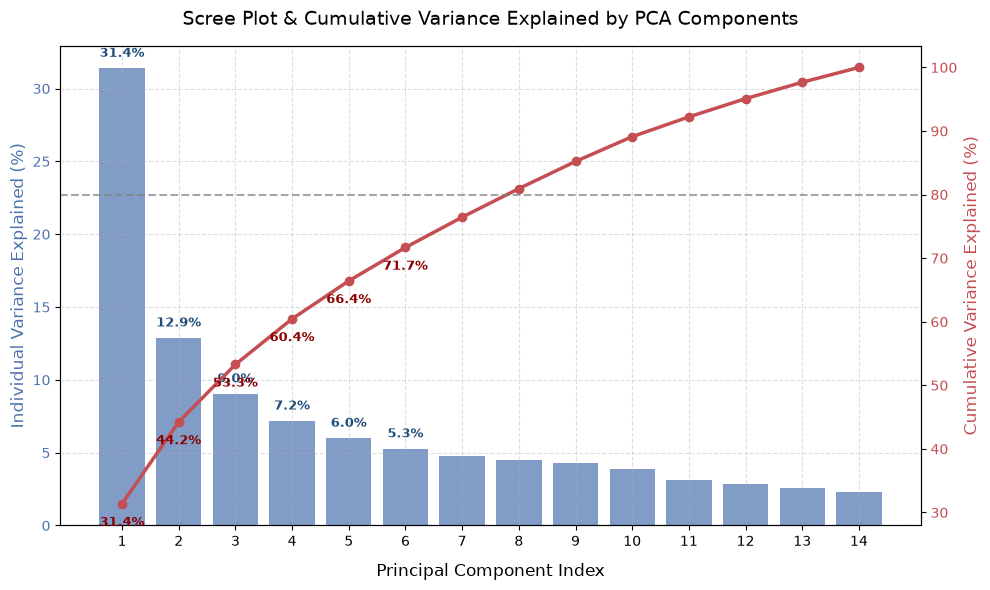

In [40]:
pca_full = PCA(n_components=len(clustering_features), random_state=42)
pca_full.fit(X_scaled)
exp_var = pca_full.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var)

# Create Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

components = np.arange(1, len(exp_var) + 1)

# Bar chart for individual variance explained
bars = ax1.bar(components, exp_var * 100, color='#4C72B0', alpha=0.7, label='Individual Explained Variance (%)')
ax1.set_xlabel('Principal Component Index', fontsize=12, labelpad=10)
ax1.set_ylabel('Individual Variance Explained (%)', fontsize=12, color='#4C72B0')
ax1.tick_params(axis='y', labelcolor='#4C72B0')
ax1.set_xticks(components)

# Line chart for cumulative variance explained
ax2 = ax1.twinx()
line = ax2.plot(components, cum_exp_var * 100, color='#C44E52', marker='o', linewidth=2.5, label='Cumulative Explained Variance (%)')
ax2.set_ylabel('Cumulative Variance Explained (%)', fontsize=12, color='#C44E52')
ax2.tick_params(axis='y', labelcolor='#C44E52')

# Add threshold line at 80% and 85%
ax2.axhline(y=80, color='gray', linestyle='--', alpha=0.7, label='80% Variance Threshold')

# Title and grid
plt.title('Scree Plot & Cumulative Variance Explained by PCA Components', fontsize=14, pad=15)
ax1.grid(True, linestyle='--', alpha=0.4)

# Annotate points for first few PCs
for i, (individual, cumulative) in enumerate(zip(exp_var, cum_exp_var)):
    if i < 6: # Annotate first 6 PCs
        ax1.annotate(f'{individual*100:.1f}%', (i + 1, individual * 100 + 0.8), ha='center', fontsize=9, color='#1F4E79', fontweight='bold')
        ax2.annotate(f'{cumulative*100:.1f}%', (i + 1, cumulative * 100 - 3.5), ha='center', fontsize=9, color='#8B0000', fontweight='bold')

plt.tight_layout()
plt.savefig('pca_variance_explained.png', dpi=300, bbox_inches='tight')

print("PCA Explained Variance Ratios:")
for idx, (ind, cum) in enumerate(zip(exp_var, cum_exp_var), 1):
    print(f"PC{idx:02d}: Individual = {ind*100:.2f}%, Cumulative = {cum*100:.2f}%")

In [41]:
for k in [3, 4, 5]:
    print(f"\n--- Clusters k={k} ---")
    
    # 1. K-Means
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_labels = km.fit_predict(X_scaled)
    km_sil = silhouette_score(X_scaled, km_labels)
    
    # 2. Agglomerative
    agg = AgglomerativeClustering(n_clusters=k)
    agg_labels = agg.fit_predict(X_scaled)
    agg_sil = silhouette_score(X_scaled, agg_labels)
    
    # 3. Gaussian Mixture
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm_labels = gmm.fit_predict(X_scaled)
    gmm_sil = silhouette_score(X_scaled, gmm_labels)
    
    print(f"K-Means Silhouette Score:         {km_sil:.4f}")
    print(f"Agglomerative Silhouette Score:   {agg_sil:.4f}")
    print(f"Gaussian Mixture Silhouette Score:{gmm_sil:.4f}")


--- Clusters k=3 ---
K-Means Silhouette Score:         0.3301
Agglomerative Silhouette Score:   0.2129
Gaussian Mixture Silhouette Score:0.2956

--- Clusters k=4 ---
K-Means Silhouette Score:         0.3309
Agglomerative Silhouette Score:   0.2243
Gaussian Mixture Silhouette Score:0.3010

--- Clusters k=5 ---
K-Means Silhouette Score:         0.3534
Agglomerative Silhouette Score:   0.2491
Gaussian Mixture Silhouette Score:0.2086


In [42]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
km_labels = km.fit_predict(X_scaled)
km_sil = silhouette_score(X_scaled, km_labels)
df['Cluster'] = km_labels

persona_mapping = {
    0: 'At-Risk Low Spenders',
    1: 'Unengaged High Spenders',
    2: 'High-Value Loyalists',
    3: 'Campaign Champions'
}

df['Persona'] = df['Cluster'].map(persona_mapping)

df['Total_Spend'] = df[spend_cols].sum(axis=1)
persona_summary = df.groupby('Persona').agg({
    'Income': 'mean',
    'Total_Spend': 'mean',
    'MntWines': 'mean',
    'Recency': 'mean',
    'Response': 'mean',
    'ID': 'count'
}).rename(columns={'ID': 'Customer_Count'}).round(2)

print("\n=== Persona Profiling Summary ===")
print(persona_summary)


=== Persona Profiling Summary ===
                           Income  Total_Spend  MntWines  Recency  Response  \
Persona                                                                       
At-Risk Low Spenders     40520.55       231.73    138.90    48.68      0.10   
Campaign Champions       71054.83      1307.67    898.67    48.67      0.67   
High-Value Loyalists     81288.07      1614.86    833.77    47.87      0.52   
Unengaged High Spenders  70897.61      1168.52    509.44    50.61      0.13   

                         Customer_Count  
Persona                                  
At-Risk Low Spenders               1441  
Campaign Champions                   30  
High-Value Loyalists                191  
Unengaged High Spenders             578  


# Implementing MLFlow

In [43]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Regression_comparison")

print("Tracking URI:", mlflow.get_tracking_uri())
print("Active experiment:", mlflow.get_experiment_by_name("Regression_comparison").name)


2026/07/24 17:27:43 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/24 17:27:43 INFO mlflow.store.db.utils: Updating database tables
2026/07/24 17:27:46 INFO mlflow.tracking.fluent: Experiment with name 'Regression_comparison' does not exist. Creating a new experiment.


Tracking URI: sqlite:///mlflow.db
Active experiment: Regression_comparison


In [44]:
models = {'Ridge Regressor': (Ridge, {'alpha':1.0}),
          'Lasso Regressor': (Lasso, {'alpha':1.0, 'random_state':42}),
          'XGBoost Regressor': (XGBRegressor, {'n_estimators':100, 'learning_rate':0.05, 'max_depth':4, 'random_state':42})}
list(models.keys())

['Ridge Regressor', 'Lasso Regressor', 'XGBoost Regressor']

In [45]:
run_ids = {}

for name, (ModelClass, params) in models.items():
    with mlflow.start_run(run_name=name) as run:
        mlflow.set_tag("algorithm", name)
        mlflow.log_params(params)

        model = ModelClass(**params)
        model.fit(X_train_processed, y_train)

        y_pred = model.predict(X_test_processed)
        proba = model.predict_proba(X_test_processed)[:, 1] if hasattr(model, "predict_proba") else None
        
        metrics = {
            'MAE': mean_absolute_error(y_test, y_pred),
            'RMSE': root_mean_squared_error(y_test, y_pred),
            'R2 Score': r2_score(y_test, y_pred),
            'MAPE': mean_absolute_percentage_error(y_test, y_pred)
            }
        
        mlflow.log_metrics(metrics)
        trusted_types = ["xgboost.core.Booster", "xgboost.sklearn.XGBRegressor"]
        
        mlflow.sklearn.log_model(
            sk_model=model, 
            artifact_path="model", 
            input_example=X_train_processed[:2],
            skops_trusted_types=trusted_types
        )
        run_ids[name] = run.info.run_id
        print(f"{name:22s} run_id={run.info.run_id}  MAE={metrics['MAE']:.3f}  RMSE={metrics['RMSE']:.3f}")


2026/07/24 17:27:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/24 17:27:47 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\pooja\Training\week 4 assessment\customer-personality-analysis
2026/07/24 17:27:52 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\pooja\Training\week 4 assessment\customer-personality-analysis
2026/07/24 17:27:52 INFO mlflow.utils.environment: Detected uv project at c:\Users\pooja\Training\week 4 assessment\customer-personality-analysis. Attempting to export requirements via 'uv export'.
2026/07/24 17:27:52 INFO mlflow.utils.uv_utils: Exported 179 dependencies via uv
2026/07/24 17:27:52 INFO mlflow.utils.environment: Successfully exported 179 requirements from uv project. Skipping package capture based inference.
2026/07/24 17:27:53 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be 

Ridge Regressor        run_id=febb29ae993044f4b7af6a9491224b09  MAE=192.029  RMSE=285.561


2026/07/24 17:27:54 INFO mlflow.utils.environment: Detected uv project at c:\Users\pooja\Training\week 4 assessment\customer-personality-analysis. Attempting to export requirements via 'uv export'.
2026/07/24 17:27:55 INFO mlflow.utils.uv_utils: Exported 179 dependencies via uv
2026/07/24 17:27:55 INFO mlflow.utils.environment: Successfully exported 179 requirements from uv project. Skipping package capture based inference.
2026/07/24 17:27:55 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Lasso Regressor        run_id=02dbcae0e6b7433db6813c3042349861  MAE=191.905  RMSE=285.220


2026/07/24 17:27:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/24 17:27:56 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\pooja\Training\week 4 assessment\customer-personality-analysis
2026/07/24 17:27:56 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\pooja\Training\week 4 assessment\customer-personality-analysis
2026/07/24 17:27:56 INFO mlflow.utils.environment: Detected uv project at c:\Users\pooja\Training\week 4 assessment\customer-personality-analysis. Attempting to export requirements via 'uv export'.
2026/07/24 17:27:56 INFO mlflow.utils.uv_utils: Exported 179 dependencies via uv
2026/07/24 17:27:56 INFO mlflow.utils.environment: Successfully exported 179 requirements from uv project. Skipping package capture based inference.
2026/07/24 17:27:57 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be 

XGBoost Regressor      run_id=1f720732f0cc4d818a808eab8e6419af  MAE=122.293  RMSE=211.505


In [46]:
experiment = mlflow.get_experiment_by_name("Regression_comparison")
runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

metric_cols = [c for c in runs_df.columns if c.startswith("metrics.")]
comparison = runs_df[["run_id", "tags.algorithm"] + metric_cols].sort_values(
    "metrics.MAE", ascending=True
).reset_index(drop=True)
comparison.columns = [c.replace("metrics.", "") for c in comparison.columns]
comparison


,run_id,tags.algorithm,MAPE,RMSE,MAE,R2 Score
0,1f720732f0cc4d818a808eab8e6419af,XGBoost Regressor,0.324197,211.505341,122.293144,0.874187
1,02dbcae0e6b7433db6813c3042349861,Lasso Regressor,0.885778,285.219793,191.905241,0.771208
2,febb29ae993044f4b7af6a9491224b09,Ridge Regressor,0.887891,285.560566,192.029467,0.770661


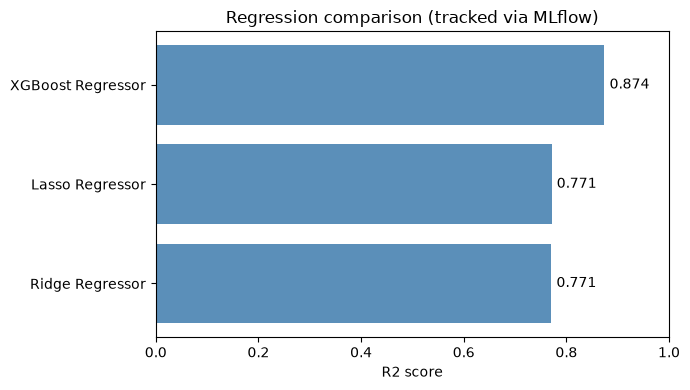

In [47]:
fig, ax = plt.subplots(figsize=(7, 4))
ordered = comparison.sort_values("R2 Score")
ax.barh(ordered["tags.algorithm"], ordered["R2 Score"], color="#5B8FB9")
ax.set_xlabel("R2 score")
ax.set_xlim(0, 1)
ax.set_title("Regression comparison (tracked via MLflow)")
for i, v in enumerate(ordered["R2 Score"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()


In [48]:
best_row = comparison.iloc[0]
best_run_id = best_row["run_id"]
best_algorithm = best_row["tags.algorithm"]

print(f"Best model: {best_algorithm}  (run_id={best_run_id},R2={best_row['R2 Score']:.3f})")

model_uri = f"runs:/{best_run_id}/model"
loaded_model = mlflow.sklearn.load_model(model_uri)

loaded_preds = loaded_model.predict(X_test_processed)
print("\nReloaded model matches its original test R2 Score:",
      np.isclose(r2_score(y_test, loaded_preds), best_row["R2 Score"]))


Best model: XGBoost Regressor  (run_id=1f720732f0cc4d818a808eab8e6419af,R2=0.874)

Reloaded model matches its original test R2 Score: True


In [49]:
registered = mlflow.register_model(model_uri=model_uri, name="best_regression_model")
print(f"Registered '{registered.name}' as version {registered.version}")

# load it back by registry name + version, instead of by run id
registry_model = mlflow.sklearn.load_model(f"models:/{registered.name}/{registered.version}")
print("Loaded from registry OK:", r2_score(y_test, registry_model.predict(X_test_processed)))


Successfully registered model 'best_regression_model'.
2026/07/24 17:27:57 WARNING mlflow.tracking._model_registry.fluent: Run with id 1f720732f0cc4d818a808eab8e6419af has no artifacts at artifact path 'model', registering model based on models:/m-f8d431db3fdd408eb1b6828bc72294a8 instead


Registered 'best_regression_model' as version 1
Loaded from registry OK: 0.8741872906684875


Created version '1' of model 'best_regression_model'.


- mlflow ui --backend-store-uri sqlite:///mlflow.db